# Geospatial Change Map 
 

## 1. Setup

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from pygris import tracts

## 2. Load Data

In [29]:
df = pd.read_csv("data/clean_rc_data.csv", dtype={"code": str})
df.head()

,code,year,number_reported,tpoverty,poverty_indicator,Total,White_alone,Black_or_African_American_alone,Asian_alone,Some_other_race_alone,Two_or_more_races,Two_races_including_some_other_race,Two_races_excluding_some_other_and_three_plus
0,48113000401,2013-2017,35.0,35.0,1,5755,3426,805,758,636,119,24,95
1,48113000401,2018-2022,35.2,32.0,1,4649,2253,1110,465,356,367,322,45
2,48113000405,2013-2017,17.6,36.8,1,2282,1315,474,279,173,41,0,41
3,48113000405,2018-2022,18.5,26.5,0,1971,845,864,79,21,162,95,67
4,48113000500,2013-2017,23.5,20.5,0,5357,3901,475,377,349,235,0,235


In [30]:
# Compute % non-White
df["pct_white"] = np.where(
    df["Total"] > 0, 100 * df["White_alone"] / df["Total"], np.nan
)
df["pct_minority"] = 100 - df["pct_white"]

# Restrict to Dallas County for the map
dallas = df[df["code"].str.startswith("48113")].copy()
print(f"Dallas tract-period rows: {len(dallas)}")
print(dallas["year"].value_counts())

Dallas tract-period rows: 544
year
2013-2017    341
2018-2022    203
Name: count, dtype: int64


## 3. Reshape to One Row Per Tract
 

In [31]:
voucher_wide = dallas.pivot(
    index="code", columns="year", values="number_reported"
).rename(columns={"2013-2017": "voucher_pre", "2018-2022": "voucher_post"})
race_post = dallas[dallas["year"] == "2018-2022"].set_index("code")[["pct_minority"]]

tract_level = voucher_wide.join(race_post, how="outer")
tract_level["change"] = tract_level["voucher_post"] - tract_level["voucher_pre"]

tract_level.reset_index().head()

,code,voucher_pre,voucher_post,pct_minority,change
0,48113000401,35.000000,35.2,51.537965,0.2
1,48113000405,17.600000,18.5,57.128361,0.9
2,48113000500,23.500000,NaN,NaN,NaN
3,48113000601,22.666667,NaN,NaN,NaN
4,48113000800,136.800000,NaN,NaN,NaN


In [32]:
# How many tracts have a usable change value (i.e., observed in both periods)?
n_change = tract_level["change"].notna().sum()
n_only_pre = (
    tract_level["voucher_pre"].notna() & tract_level["voucher_post"].isna()
).sum()
n_only_post = (
    tract_level["voucher_pre"].isna() & tract_level["voucher_post"].notna()
).sum()
n_neither = (
    tract_level["voucher_pre"].isna() & tract_level["voucher_post"].isna()
).sum()

## 4. Load Dallas County Shapefile

In [33]:
dallas_shp = tracts(state="TX", county="113", year=2020, cache=True)
dallas_shp = dallas_shp[["GEOID", "geometry"]].rename(columns={"GEOID": "code"})

dallas_map = dallas_shp.merge(tract_level.reset_index(), on="code", how="left")
print(f"Dallas County: {len(dallas_map)} tracts on map")

Using FIPS code '48' for input 'TX'
Dallas County: 645 tracts on map


## 5. Plot the Change Map
 

Color scale: -63 to +63 change in HCV households


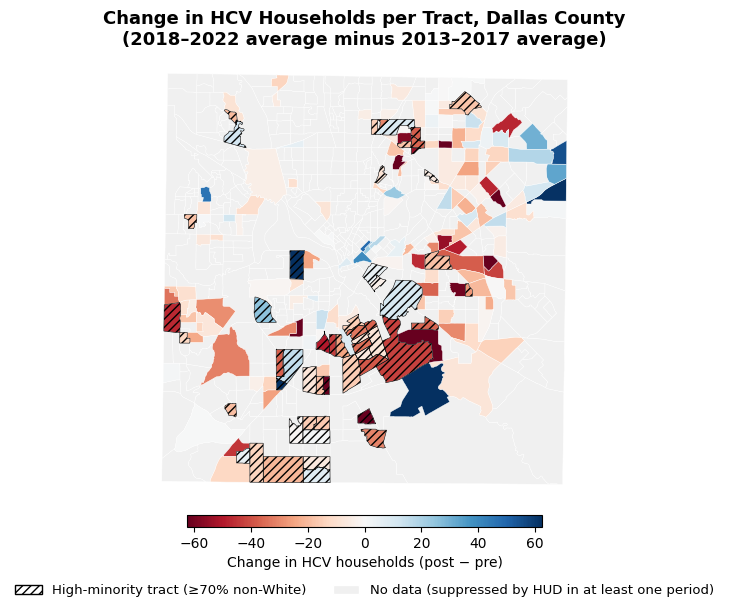

In [38]:
MINORITY_THRESHOLD = 70  # % non-White cutoff for hatching

# Cap at the 95th percentile of |change| to keep extreme outliers from
# washing out the rest of the map.
abs_change = dallas_map["change"].abs().dropna()
vmax = np.percentile(abs_change, 95)
vmin = -vmax
print(f"Color scale: {vmin:.0f} to +{vmax:.0f} change in HCV households")

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

# Light gray base layer for tracts with no change data
dallas_map.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.3)

# Tracts with usable change values: diverging fill
has_change = dallas_map.dropna(subset=["change"])
has_change.plot(
    ax=ax,
    column="change",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    edgecolor="white",
    linewidth=0.3,
)

# Hatch high-minority tracts (regardless of whether change is observed)
high_min = dallas_map[dallas_map["pct_minority"] >= MINORITY_THRESHOLD]
high_min.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4,
    hatch="////",
)

ax.set_axis_off()
ax.set_title(
    "Change in HCV Households per Tract, Dallas County\n"
    "(2018–2022 average minus 2013–2017 average)",
    fontsize=13,
    fontweight="bold",
)

# Diverging colorbar
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.04,
    pad=0.02,
    shrink=0.6,
    aspect=30,
)
cbar.set_label("Change in HCV households (post − pre)", fontsize=10)

# Legend for hatching and suppressed tracts
hp_patch = mpatches.Patch(
    facecolor="white",
    edgecolor="black",
    hatch="////",
    label=f"High-minority tract (≥{MINORITY_THRESHOLD}% non-White)",
)
nodata_patch = mpatches.Patch(
    facecolor="#f0f0f0",
    edgecolor="white",
    label="No data (suppressed by HUD in at least one period)",
)
fig.legend(
    handles=[hp_patch, nodata_patch],
    loc="outside lower center",
    ncol=2,
    frameon=False,
    fontsize=9.5,
)

plt.show()

## 6. Summary  

In [35]:
valid = tract_level.dropna(subset=["change", "pct_minority"]).copy()
valid["high_minority"] = (valid["pct_minority"] >= MINORITY_THRESHOLD).astype(int)

summary = (
    valid.groupby("high_minority")
    .agg(
        n_tracts=("change", "size"),
        mean_change=("change", "mean"),
        median_change=("change", "median"),
        share_losing=("change", lambda x: (x < 0).mean()),
    )
    .rename(
        index={
            0: f"<{MINORITY_THRESHOLD}% non-White",
            1: f"≥{MINORITY_THRESHOLD}% non-White",
        }
    )
    .round(2)
)
print("Average voucher change by tract racial composition:")
print(summary)

Average voucher change by tract racial composition:
                n_tracts  mean_change  median_change  share_losing
high_minority                                                     
<70% non-White       146        -9.34           -7.8          0.73
≥70% non-White        54       -15.66          -17.4          0.80


High-minority tracts lost 6.0 more voucher households on average than lower-minority tracts. Consistent with SAFMR redirecting voucher families away from high-minority neighborhoods.
